In [1]:
from python import embeddings
from python import recompute
from python import models
from python import pca
from pathlib import Path
import matplotlib.pyplot as plt

/home/alch/Documents/homework/stats170a/project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/alch/Documents/homework/stats170a/project/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [2]:
EMBEDDINGS_MODEL = "sentence-transformers/all-mpnet-base-v2"
NLP_MODEL = "en_core_web_sm"

ROOT_DIRECTORY = Path.cwd().resolve()
DATA_DIRECTORY = ROOT_DIRECTORY / "data"
ANCHOR_DIRECTORY = DATA_DIRECTORY / "anchors"
OUTPUT_DIRECTORY = ROOT_DIRECTORY / "outputs"

DATA_FILE_LOCATION = DATA_DIRECTORY / "processed" / "table.parquet"

TOPICS = {
    topic: {
        "Positive Anchors": ANCHOR_DIRECTORY
        / f"{topic.lower()}_positive_anchor_sentences.csv",
        "Negative Anchors": ANCHOR_DIRECTORY
        / f"{topic.lower()}_negative_anchor_sentences.csv",
    }
    for topic in ["Religion", "Politics", "Science"]
}
plt.rcParams.update({"font.size": 20})

In [3]:
dataframe, embeddings_model, nlp_model, gaussian_mixture_model, standard_scalar = (
    embeddings.initialize_models(
        embeddings_model_name=EMBEDDINGS_MODEL,
        data_file_location=DATA_FILE_LOCATION,
        nlp_name=NLP_MODEL,
        random_state=420,
    )
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 20966.78it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
positive_anchor_embeddings = embeddings.calculate_anchor_embeddings(
    location=TOPICS["Religion"]["Positive Anchors"],
    embeddings_model=embeddings_model,
)
negative_anchor_embeddings = embeddings.calculate_anchor_embeddings(
    location=TOPICS["Religion"]["Negative Anchors"],
    embeddings_model=embeddings_model,
)
topic_axis = embeddings.calculate_topic_axis(
    positive_vector=embeddings.calculate_average_vector(positive_anchor_embeddings),
    negative_vector=embeddings.calculate_average_vector(negative_anchor_embeddings),
)
example_topic_speech_embeddings = embeddings.calculate_sentence_embeddings(
    sentences=embeddings.split_speech_into_sentences(
        speech=dataframe["speech"].iloc[64], nlp_model=nlp_model
    ),
    embeddings_model=embeddings_model,
)
random_control_speech_embeddings = embeddings.calculate_sentence_embeddings(
    sentences=embeddings.split_speech_into_sentences(
        speech=dataframe["speech"].iloc[0], nlp_model=nlp_model
    ),
    embeddings_model=embeddings_model,
)

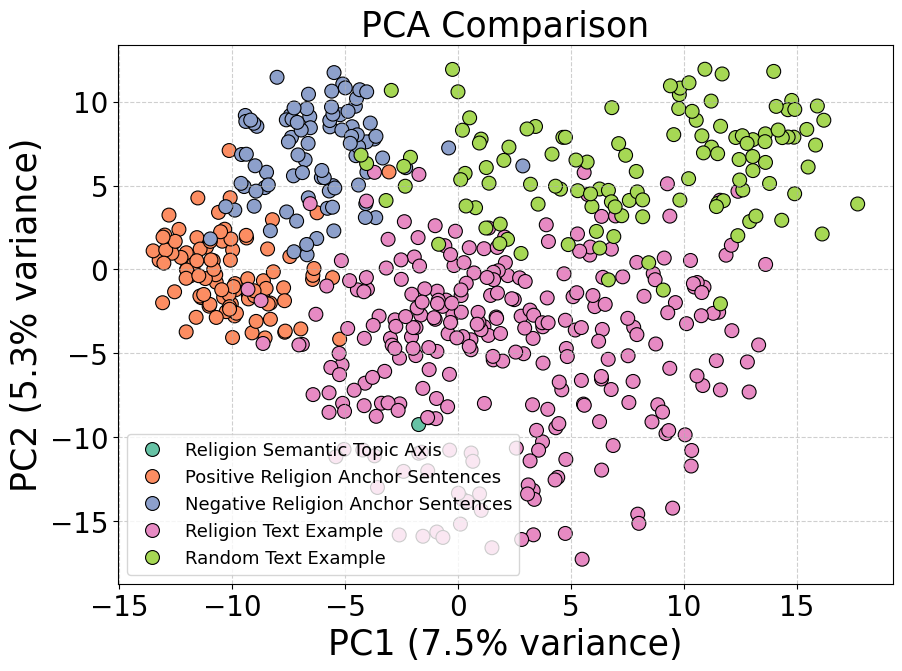

In [6]:
pca.save_pca_plot(
    topic="Religion",
    scalar=standard_scalar,
    number_of_components=2,
    positive_anchor_embeddings=positive_anchor_embeddings,
    negative_anchor_embeddings=negative_anchor_embeddings,
    topic_axis=topic_axis,
    example_topic_speech_embeddings=example_topic_speech_embeddings,
    random_control_speech_embeddings=random_control_speech_embeddings,
    save_location=OUTPUT_DIRECTORY / "religion_pca",
    print_plot=True,
)

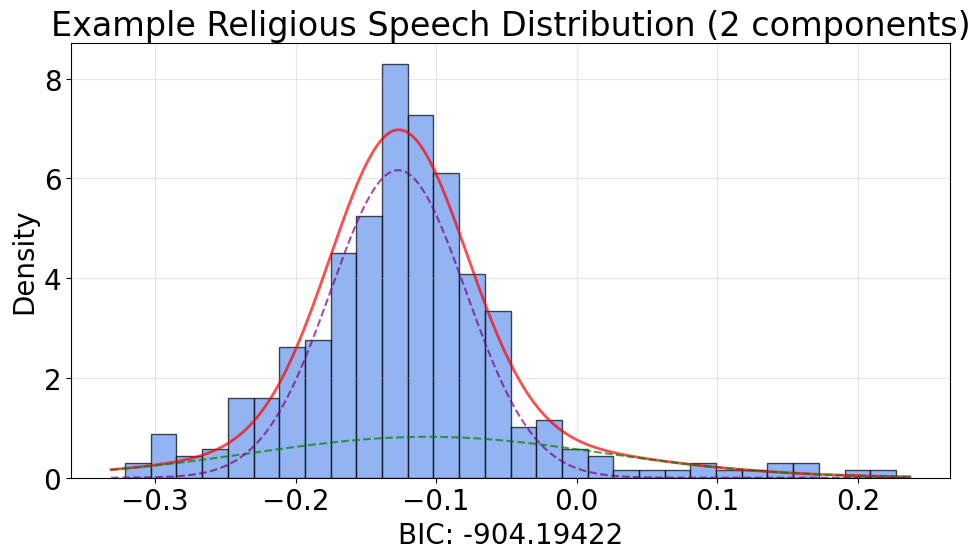

In [7]:
models.plot_gmm_distribution(
    distribution=dataframe["Religion distribution"].iloc[473],
    gaussian_mixture_model=gaussian_mixture_model,
    save_location=OUTPUT_DIRECTORY / "religion_example_gmm",
    print_plot=True,
)

In [8]:
models.compute_all_linear_regression_plots(
    group_by="cyear",
    topics=TOPICS,
    dataframe=dataframe,
    save_location=OUTPUT_DIRECTORY,
    print_plot=True
)

TypeError: compute_all_linear_regression_plots() got an unexpected keyword argument 'print_plot'